# Notebook 07 — Voice of Customer (Topic Analysis)

## 1. Setup

In [1]:
import sys, io, base64
import pandas as pd
import plotly.graph_objects as go
from pathlib import Path
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
from IPython.display import display, HTML

PROJECT_ROOT = Path(".").resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

INTERIM_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Environment ready.")

Environment ready.


## 2. Load data

In [2]:
df   = pd.read_parquet(INTERIM_DIR / "analysis_ready.parquet")
sbux = df[df["brand_category"] == "Starbucks"]
pos  = sbux[sbux["star_tier"] == "Positive"]
neg  = sbux[sbux["star_tier"] == "Critical"]

print(f"Starbucks reviews : {len(sbux):,}")
print(f"Positive (4–5★)   : {len(pos):,}  ({len(pos)/len(sbux)*100:.1f}%)")
print(f"Critical (1–2★)   : {len(neg):,}  ({len(neg)/len(sbux)*100:.1f}%)")

Starbucks reviews : 11,675
Positive (4–5★)   : 4,947  (42.4%)
Critical (1–2★)   : 5,557  (47.6%)


## 3. Topic scorecard

Reviews are multi-label tagged, so a single review can appear under multiple topics. Topic totals exceed the review count.

In [3]:
topic_order = ["Service", "Food Quality", "General", "Ambiance", "Wait Time", "Price", "Cleanliness"]

rows = []
for topic in topic_order:
    # Multi-label: a review counts toward a topic if that topic appears anywhere in its tag string
    mask    = sbux["topic_tags"].str.contains(topic, regex=False)
    total   = mask.sum()
    pos_cnt = (mask & (sbux["star_tier"] == "Positive")).sum()
    neu_cnt = (mask & (sbux["star_tier"] == "Neutral")).sum()
    neg_cnt = (mask & (sbux["star_tier"] == "Critical")).sum()
    if total == 0:
        continue
    rows.append({
        "Topic":           topic,
        "Total":           total,
        "Positive":        pos_cnt,
        "Neutral":         neu_cnt,
        "Critical":        neg_cnt,
        "Pos Rate %":      round(pos_cnt / total * 100, 1),
        "Failure Rate %":  round(neg_cnt / total * 100, 1),
    })

tbl = pd.DataFrame(rows)
print(f"Note: topic counts reflect multi-label matching; totals exceed {len(sbux):,} reviews.")
display(tbl)

Note: topic counts reflect multi-label matching; totals exceed 11,675 reviews.


,Topic,Total,Positive,Neutral,Critical,Pos Rate %,Failure Rate %
0,Service,8822,3921,839,4062,44.4,46.0
1,Food Quality,7424,2935,798,3691,39.5,49.7
2,General,445,190,35,220,42.7,49.4
3,Ambiance,2342,1456,392,494,62.2,21.1
4,Wait Time,5566,2220,597,2749,39.9,49.4
5,Price,1027,244,96,687,23.8,66.9
6,Cleanliness,1609,760,197,652,47.2,40.5


## 4. Topic volume by sentiment tier

In [4]:
display(tbl)

tbl_chart = tbl.sort_values("Total", ascending=True)

fig = go.Figure()
fig.add_trace(go.Bar(
    name="Positive (4–5★)",
    x=tbl_chart["Positive"],
    y=tbl_chart["Topic"],
    orientation="h",
    marker_color="#00704A",
))
fig.add_trace(go.Bar(
    name="Neutral (3★)",
    x=tbl_chart["Neutral"],
    y=tbl_chart["Topic"],
    orientation="h",
    marker_color="#f4a261",
))
fig.add_trace(go.Bar(
    name="Critical (1–2★)",
    x=tbl_chart["Critical"],
    y=tbl_chart["Topic"],
    orientation="h",
    marker_color="#d62728",
))
fig.update_layout(
    barmode="stack",
    title=dict(text="Starbucks — Review Volume by Topic and Sentiment Tier", font=dict(size=16)),
    xaxis_title="Review Count",
    yaxis_title="Topic",
    plot_bgcolor="white",
    paper_bgcolor="white",
    xaxis=dict(showgrid=True, gridcolor="#eeeeee"),
    yaxis=dict(showgrid=False),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    width=860, height=430,
    margin=dict(t=80, b=50, l=110, r=40),
)
fig.write_html(str(FIGURES_DIR / "07_topic_volume.html"))
fig.show()

,Topic,Total,Positive,Neutral,Critical,Pos Rate %,Failure Rate %
0,Service,8822,3921,839,4062,44.4,46.0
1,Food Quality,7424,2935,798,3691,39.5,49.7
2,General,445,190,35,220,42.7,49.4
3,Ambiance,2342,1456,392,494,62.2,21.1
4,Wait Time,5566,2220,597,2749,39.9,49.4
5,Price,1027,244,96,687,23.8,66.9
6,Cleanliness,1609,760,197,652,47.2,40.5


## 5. Sentiment composition by topic (%)

In [5]:

tbl_rate = tbl.sort_values("Pos Rate %", ascending=True)

display(tbl_rate[["Topic", "Pos Rate %", "Failure Rate %"]])

fig2 = go.Figure()
fig2.add_trace(go.Bar(
    name="Positive (4–5★)",
    x=tbl_rate["Pos Rate %"],
    y=tbl_rate["Topic"],
    orientation="h",
    marker_color="#00704A",
    text=[f"{v}%" for v in tbl_rate["Pos Rate %"]],
    textposition="inside",
    textfont=dict(color="white", size=11),
))
fig2.add_trace(go.Bar(
    name="Neutral (3★)",
    x=100 - tbl_rate["Pos Rate %"] - tbl_rate["Failure Rate %"],
    y=tbl_rate["Topic"],
    orientation="h",
    marker_color="#f4a261",
))
fig2.add_trace(go.Bar(
    name="Critical (1–2★)",
    x=tbl_rate["Failure Rate %"],
    y=tbl_rate["Topic"],
    orientation="h",
    marker_color="#d62728",
    text=[f"{v}%" for v in tbl_rate["Failure Rate %"]],
    textposition="inside",
    textfont=dict(color="white", size=11),
))
fig2.update_layout(
    barmode="stack",
    title=dict(text="Starbucks — Sentiment Composition by Topic (% of Topic Total)", font=dict(size=16)),
    xaxis=dict(
        title="Share of Reviews (%)",
        range=[0, 100],
        ticksuffix="%",
        showgrid=True,
        gridcolor="#eeeeee",
    ),
    yaxis=dict(title="Topic", showgrid=False),
    plot_bgcolor="white",
    paper_bgcolor="white",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    width=860, height=430,
    margin=dict(t=80, b=50, l=110, r=40),
)
fig2.write_html(str(FIGURES_DIR / "07_topic_rate.html"))
fig2.show()


,Topic,Pos Rate %,Failure Rate %
5,Price,23.8,66.9
1,Food Quality,39.5,49.7
4,Wait Time,39.9,49.4
2,General,42.7,49.4
0,Service,44.4,46.0
6,Cleanliness,47.2,40.5
3,Ambiance,62.2,21.1


## 6. Word clouds (positive vs. critical)

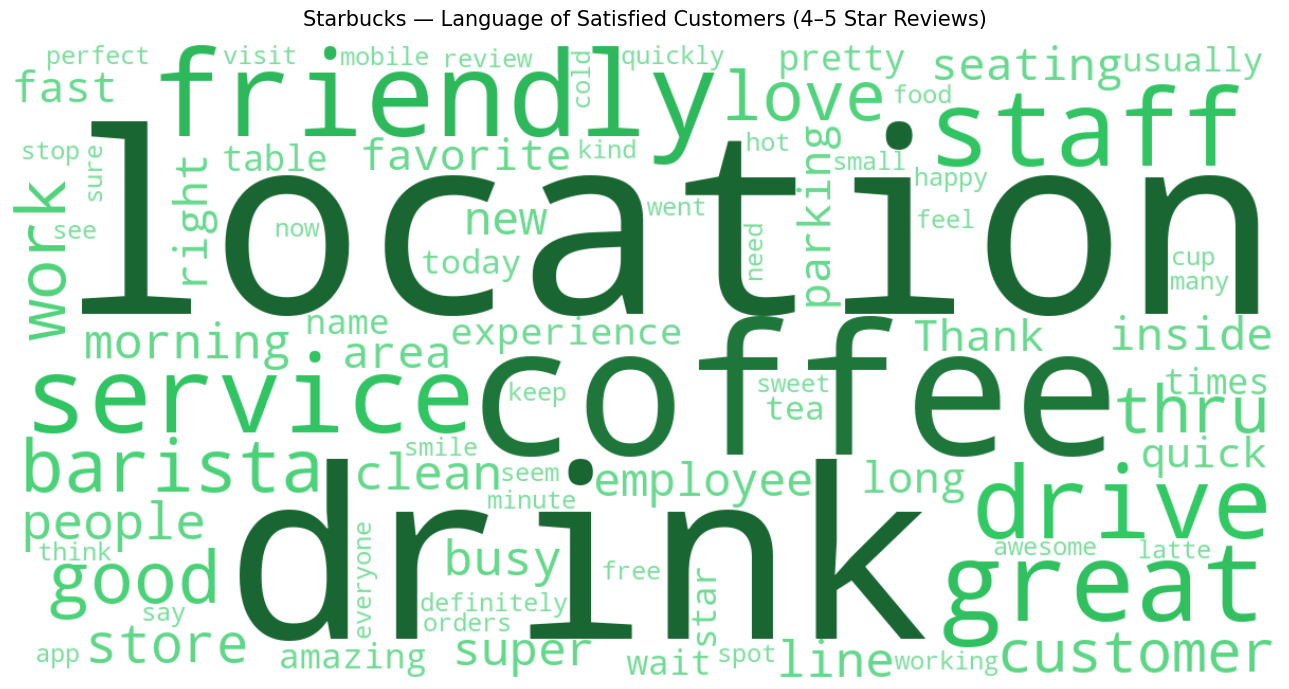

Positive word cloud saved.


In [6]:
shared_stops = {
    "get", "got", "go", "one", "also", "really", "just", "even", "would", "could",
    "will", "like", "us", "im", "ive", "dont", "its", "the", "starbucks",
    "place", "time", "day", "back", "make", "made", "always", "never", "still",
    "every", "much", "well", "nice", "best", "really", "very", "little", "bit",
    "lot", "thing", "things", "way", "said", "came", "ve", "re", "ll", "s", "t", "m",
    "come", "know", "take", "want", "try", "used", "use", "two", "first", "last",
    "around", "going", "though", "since", "gave", "give", "asked", "ask",
    "told", "tell", "left", "found", "order", "ordered", "getting",
}
stopwords = STOPWORDS | shared_stops

def green_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    ratio = max(0.0, min(1.0, (font_size - 10) / 180))
    lightness = int(72 - ratio * 47)
    return f"hsl(140, 60%, {lightness}%)"

pos_text = " ".join(pos["text"].dropna().astype(str).tolist())
wc_pos = WordCloud(
    width=1200, height=600, background_color="white",
    stopwords=stopwords, color_func=green_color_func,
    max_words=80, min_font_size=10, collocations=False, random_state=42,
).generate(pos_text)

fig_pos, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wc_pos, interpolation="bilinear")
ax.axis("off")
ax.set_title("Starbucks — Language of Satisfied Customers (4–5 Star Reviews)", fontsize=15, pad=14)
plt.tight_layout()

buf = io.BytesIO()
fig_pos.savefig(buf, format="png", dpi=150, bbox_inches="tight")
buf.seek(0)
img_b64 = base64.b64encode(buf.read()).decode("utf-8")
html_content = (
    '<html><head><meta charset="utf-8"></head>'
    '<body style="margin:0;background:white;text-align:center;">'
    f'<img src="data:image/png;base64,{img_b64}" style="max-width:100%;">'
    "</body></html>"
)
with open(str(FIGURES_DIR / "07_wordcloud_positive.html"), "w") as f:
    f.write(html_content)
plt.show()
print("Positive word cloud saved.")

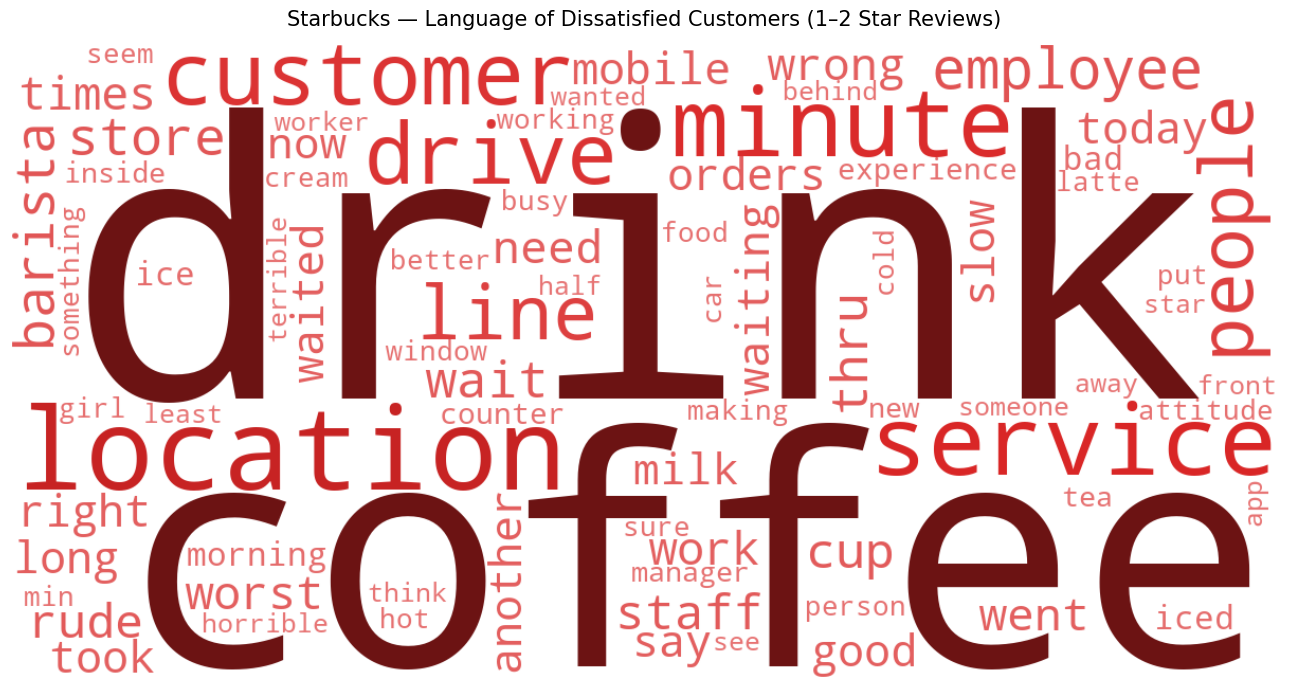

Critical word cloud saved.


In [7]:
def red_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    ratio = max(0.0, min(1.0, (font_size - 10) / 180))
    lightness = int(72 - ratio * 47)
    return f"hsl(0, 70%, {lightness}%)"

neg_text = " ".join(neg["text"].dropna().astype(str).tolist())
wc_neg = WordCloud(
    width=1200, height=600, background_color="white",
    stopwords=stopwords, color_func=red_color_func,
    max_words=80, min_font_size=10, collocations=False, random_state=42,
).generate(neg_text)

fig_neg, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wc_neg, interpolation="bilinear")
ax.axis("off")
ax.set_title("Starbucks — Language of Dissatisfied Customers (1–2 Star Reviews)", fontsize=15, pad=14)
plt.tight_layout()

buf = io.BytesIO()
fig_neg.savefig(buf, format="png", dpi=150, bbox_inches="tight")
buf.seek(0)
img_b64 = base64.b64encode(buf.read()).decode("utf-8")
html_content = (
    '<html><head><meta charset="utf-8"></head>'
    '<body style="margin:0;background:white;text-align:center;">'
    f'<img src="data:image/png;base64,{img_b64}" style="max-width:100%;">'
    "</body></html>"
)
with open(str(FIGURES_DIR / "07_wordcloud_critical.html"), "w") as f:
    f.write(html_content)
plt.show()
print("Critical word cloud saved.")

## Key Findings

- Service is the most-discussed topic at 8,822 mentions (44.4% positive, 46.0% critical). Food Quality follows at 7,424 mentions (39.5% positive, 49.7% critical).
- Wait Time has 5,566 mentions with only 39.9% positive. Nearly half are critical.
- Ambiance is the strongest topic: 62.2% positive rate, only 21.1% critical across 2,342 mentions.
- Price has the worst failure rate at 66.9% critical, though it appears in only 1,027 mentions.
- Cleanliness sits at 1,609 mentions with a 40.5% critical rate. Fewer people bring it up, but when they do it skews negative.